<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Monte_Carlo_para_previs%C3%A3o_de_pre%C3%A7os.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python para finanças - simulação Monte Carlos para previsão de preços de ações

## Importação das bibliotecas e preparação da base de dados

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("/content/acoes.csv")
df

,Date,GOL,CVC,WEGE,MGLU,TOTS,BOVA
0,2015-01-02,14.990000,15.20,11.846200,0.232812,35.732101,47.259998
1,2015-01-05,14.850000,15.00,11.926900,0.237187,34.634201,46.320000
2,2015-01-06,15.210000,14.80,11.750000,0.234062,32.468300,46.580002
3,2015-01-07,14.550000,14.67,11.615400,0.241875,32.238701,48.150002
4,2015-01-08,14.270000,14.15,11.811500,0.240000,32.987301,48.509998
...,...,...,...,...,...,...,...
1441,2020-10-27,18.600000,14.17,83.239998,25.450001,28.500000,95.800003
1442,2020-10-28,16.920000,12.77,79.139999,24.629999,27.500000,92.430000
1443,2020-10-29,16.610001,12.68,80.029999,25.360001,28.500000,92.910004
1444,2020-10-30,15.690000,12.28,75.830002,24.629999,27.000000,90.660004


In [3]:
figura = px.line(title = "Histórico do preço das ações")
for i in df.columns[1:]:
  figura.add_scatter(x = df["Date"], y = df[i], name = i)
figura.show()

In [4]:
df = pd.DataFrame(df["BOVA"])
df

,BOVA
0,47.259998
1,46.320000
2,46.580002
3,48.150002
4,48.509998
...,...
1441,95.800003
1442,92.430000
1443,92.910004
1444,90.660004


In [5]:
df_normalizado = df.copy()

In [6]:
for i in df:
  df_normalizado[i] = df[i] / df[i][0]
df_normalizado

,BOVA
0,1.000000
1,0.980110
2,0.985612
3,1.018832
4,1.026449
...,...
1441,2.027084
1442,1.955777
1443,1.965933
1444,1.918324


In [7]:
df_taxa_retorno = np.log(1 + df_normalizado.pct_change())
df_taxa_retorno

,BOVA
0,NaN
1,-0.020090
2,0.005597
3,0.033150
4,0.007449
...,...
1441,-0.010074
1442,-0.035811
1443,0.005180
1444,-0.024515


In [8]:
df_taxa_retorno.fillna(0, inplace = True)
df_taxa_retorno

,BOVA
0,0.000000
1,-0.020090
2,0.005597
3,0.033150
4,0.007449
...,...
1441,-0.010074
1442,-0.035811
1443,0.005180
1444,-0.024515


## Calculo do drift

In [12]:
media = df_taxa_retorno.mean()
varianca = df_taxa_retorno.var()

In [14]:
drift = media - (0.5 * varianca)

In [15]:
drift

,0
BOVA,0.000312


## Calculo dos retornos diários

In [18]:
dias_frente = 50
simulacoes = 10

In [16]:
desvio_padrao = df_taxa_retorno.std()
desvio_padrao

,0
BOVA,0.017426


In [19]:
Z = stats.norm.ppf(np.random.rand(dias_frente, simulacoes))

In [20]:
Z.shape

(50, 10)

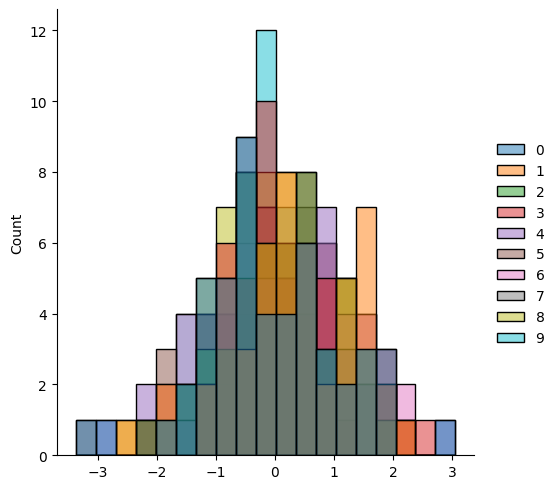

In [24]:
sns.displot(Z)

In [26]:
retornos_diarios = np.exp(drift.values + (desvio_padrao.values * Z))

In [ ]:
retornos_diarios

## Previsão de preços futuros

In [34]:
previsoes = np.zeros_like(retornos_diarios)

In [38]:
df.iloc[-1]

,1445
BOVA,92.410004


In [ ]:
previsoes[0] = df.iloc[-1]

In [41]:
for dia in range(1, dias_frente):
  previsoes[dia] = previsoes[dia - 1] * retornos_diarios[dia]
previsoes

array([[ 92.41000366,  92.41000366,  92.41000366,  92.41000366,
         92.41000366,  92.41000366,  92.41000366,  92.41000366,
         92.41000366,  92.41000366],
       [ 92.67380385,  90.73632779,  91.08370965,  92.20463555,
         92.47536597,  92.74726705,  91.65210436,  91.00496395,
         91.16309384,  92.13641521],
       [ 95.10217585,  91.29879367,  90.70602491,  90.72561865,
         91.377189  ,  93.86584187,  92.37996821,  90.59940259,
         91.12185143,  91.73222348],
       [ 93.2464843 ,  91.62174727,  92.47121981,  90.90842852,
         92.49446354,  94.98444299,  91.44974925,  90.11694718,
         89.26160141,  92.02081982],
       [ 94.4426176 ,  91.98920318,  91.94351765,  91.85848606,
         95.22930914,  98.4329041 ,  94.69893263,  90.35972843,
         88.98650542,  89.51571726],
       [ 94.44776781,  90.83178549,  93.85096357,  90.48299149,
         96.6908278 ,  97.02949223,  95.06806358,  89.42944196,
         91.15472137,  90.5073111 ],
       [ 9

## Gráfico das previsões

In [45]:
figura = px.line(title = "Previsões do preço das ações - simulações")
for i in range(len(previsoes.T)):
  figura.add_scatter(y = previsoes[i])
figura.show()

## Compração das previsões com os preços reais

In [55]:
import yfinance as yf

dataset_bova = yf.download(
    "BOVA11.SA",
    start="2020-11-04",
    end="2020-12-14"
)["Close"]

print(dataset_bova)


/tmp/ipython-input-1248609652.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Ticker       BOVA11.SA
Date                  
2020-11-04   94.160004
2020-11-05   96.949997
2020-11-06   97.190002
2020-11-09   99.500000
2020-11-10  101.000000
2020-11-11  100.889999
2020-11-12   98.699997
2020-11-13  100.830002
2020-11-16  102.510002
2020-11-17  103.099998
2020-11-18  101.919998
2020-11-19  102.730003
2020-11-23  103.279999
2020-11-24  105.720001
2020-11-25  105.830002
2020-11-26  106.019997
2020-11-27  106.440002
2020-11-30  105.000000
2020-12-01  107.050003
2020-12-02  107.750000
2020-12-03  108.150002
2020-12-04  109.430000
2020-12-07  109.309998
2020-12-08  109.440002
2020-12-09  108.769997
2020-12-10  110.699997
2020-12-11  110.790001


In [56]:
dataset_bova.to_csv("bova_teste.csv")

In [58]:
dataset_bova = pd.read_csv("bova_teste.csv")
dataset_bova

,Date,BOVA11.SA
0,2020-11-04,94.160004
1,2020-11-05,96.949997
2,2020-11-06,97.190002
3,2020-11-09,99.500000
4,2020-11-10,101.000000
5,2020-11-11,100.889999
6,2020-11-12,98.699997
7,2020-11-13,100.830002
8,2020-11-16,102.510002
9,2020-11-17,103.099998


In [61]:
simulacoes1 = previsoes.T[0][0: len(dataset_bova)]
simulacoes1

array([92.41000366, 92.67380385, 95.10217585, 93.2464843 , 94.4426176 ,
       94.44776781, 93.2842909 , 95.21469266, 93.44486416, 92.73415651,
       92.9957366 , 91.24152088, 87.06259246, 88.04612249, 88.82875553,
       88.29536254, 83.29010417, 82.68392258, 82.17814684, 86.70376939,
       86.45263138, 85.75518035, 87.70403232, 86.10818442, 88.92315415,
       87.59768028, 90.16953156])

In [62]:
len(simulacoes1)

27

In [69]:
np.sum(abs(simulacoes1 - dataset_bova["BOVA11.SA"])) / len(simulacoes1)

np.float64(14.523063645634865)

In [70]:
from sklearn.metrics import mean_absolute_error

In [71]:
mean_absolute_error(dataset_bova["BOVA11.SA"], simulacoes1)

14.523063645634865

In [72]:
erros = []
for i in range(len(previsoes.T)):
  simulacao = previsoes.T[i][0:len(dataset_bova)]
  erros.append(mean_absolute_error(dataset_bova["BOVA11.SA"], simulacao))
erros

[14.523063645634865,
 10.800585466313798,
 14.759589401048352,
 11.26670434733223,
 12.008922674707167,
 13.547112881690442,
 5.271765803958306,
 12.907878772234396,
 11.815236591282847,
 14.563212952608525]

In [76]:
figura = px.line(title = "Previsões do preço das ações - simulações")
figura.add_scatter(y = dataset_bova["BOVA11.SA"], name = "Valor real")
figura.add_scatter(y = previsoes.T[2], name = "Pior simulação")
figura.add_scatter(y = previsoes.T[6], name = "Melhor simualação")